In [ ]:
from utils_activations import *
from utils import makefolder

rcpsize = 20
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
global_center_flag = 1
min_token_length = 3
n_tokens = min_token_length 
k_recall = 3

for avg_tokens in [0,1]:

  input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]
  input_path_B = input_paths['english'][model_name]['matching']['1'][data_var]

  all_activations_A = collect_data(input_path_A, 
                                  min_token_length, 
                                  n_files,
                                  model_name,
                                  avg_tokens,
                                  )
  all_activations_B = collect_data(input_path_B, 
                                  min_token_length, 
                                  n_files,
                                  model_name,
                                  avg_tokens,
                                  )
  
  layers = list(range(1, depths[model_name] + 1))
  layer_vals = reduce_list_half_preserve_extremes(layers)


  recalls_0 = np.empty(len(layer_vals))
  recalls_sem = np.empty_like(recalls_0)
  recalls_syn = np.empty_like(recalls_0)
  recalls_sem_perm = np.empty_like(recalls_0)
  recalls_syn_perm = np.empty_like(recalls_0)
  
  layer_id = -1
  for layer in tqdm(layer_vals,desc='layer_vals'):
    layer_id += 1
    act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing_sem_data(
        model_name=model_name,
        all_activations=all_activations_A, 
        layer=layer, 
        space_index='A',
        global_center_flag=global_center_flag,
        min_token_length=min_token_length,
        avg_tokens=avg_tokens,
        n_tokens=n_tokens,
    )
    act_B, _, _, global_center_B = preprocessing_sem_data(
        model_name=model_name,
        all_activations=all_activations_B, 
        layer=layer, 
        space_index='B',
        global_center_flag=global_center_flag,
        min_token_length=min_token_length,
        avg_tokens=avg_tokens,
        n_tokens=n_tokens,
        centroids=False,
    )
    idx = jnp.arange(act_A.shape[0], dtype=jnp.int32)
    key_idx = jax.random.PRNGKey(42)
    permuted_idx = jax.random.permutation(key_idx, act_A.shape[0])  # perm of [0..N-1]

    syn_centroids_A = batched_remove_centroid_projections(syn_centroids_A,idx,sem_centroids_A)

    ### X retriving P
    cos_matrix_0 = all_cosine_similarities(act_A, act_B)
    r_0 = recall_at_k_jax(cos_matrix_0, k_recall)
    recalls_0[layer_id] = float(r_0)

    ### semantic ablation
    act_A_sem = batched_remove_centroid_projections(act_A,idx,sem_centroids_A)
    cos_matrix_sem = all_cosine_similarities(act_A_sem, act_B)
    r_sem = recall_at_k_jax(cos_matrix_sem, k_recall)
    recalls_sem[layer_id] = float(r_sem)

    ### syntax ablation
    act_A_syn = batched_remove_centroid_projections(act_A,idx,syn_centroids_A)
    cos_matrix_syn = all_cosine_similarities(act_A_syn, act_B)
    r_syn = recall_at_k_jax(cos_matrix_syn, k_recall)
    recalls_syn[layer_id] = float(r_syn)

    ### random controls
    act_A_sem_perm = batched_remove_centroid_projections(act_A,permuted_idx,sem_centroids_A)
    cos_matrix_sem_perm = all_cosine_similarities(act_A_sem_perm, act_B)
    r_sem_perm = recall_at_k_jax(cos_matrix_sem_perm, k_recall)
    recalls_sem_perm[layer_id] = float(r_sem_perm)

    act_A_syn_perm = batched_remove_centroid_projections(act_A,permuted_idx,syn_centroids_A)
    cos_matrix_syn_perm = all_cosine_similarities(act_A_syn_perm, act_B)
    r_syn_perm = recall_at_k_jax(cos_matrix_syn_perm, k_recall)
    recalls_syn_perm[layer_id] = float(r_syn_perm)

  ### Saving
  resultsfolder = makefolder(base='results/recall/sem/',
                          create_folder=True,
                          model_name=model_name,
                          avg_tokens=avg_tokens,
                          min_token_length=min_token_length,
                          global_center_flag=global_center_flag,
                          k=k_recall,
                          )
  # Prepare data to save
  layer_vals_arr = np.array(layer_vals)
  rel_depths = layer_vals_arr / depths[model_name]

  save_path = os.path.join(resultsfolder, f"recall_k{k_recall}.npz")

  np.savez(
      save_path,
      layer_vals=layer_vals_arr,
      rel_depths=rel_depths,
      recalls_0=recalls_0,
      recalls_sem=recalls_sem,
      recalls_syn=recalls_syn,
      recalls_sem_perm=recalls_sem_perm,
      recalls_syn_perm=recalls_syn_perm,
  )


In [1]:
import os
import numpy as np
from utils import makefolder,depths
import matplotlib.pyplot as plt

n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
global_center_flag = 1
min_token_length = 3
n_tokens = min_token_length 
k_recall = 3
avg_tokens = 0

resultsfolder = makefolder(base='results/recall/sem/',
                        model_name=model_name,
                        avg_tokens=avg_tokens,
                        min_token_length=min_token_length,
                        global_center_flag=global_center_flag,
                        k=k_recall,
                        )

results_path = os.path.join(resultsfolder, f"recall_k{k_recall}.npz")

data = np.load(results_path)

layer_vals      = data["layer_vals"]
rel_depths      = data["rel_depths"]
recalls_0       = data["recalls_0"]
recalls_sem     = data["recalls_sem"]
recalls_syn     = data["recalls_syn"]
recalls_sem_perm = data["recalls_sem_perm"]
recalls_syn_perm = data["recalls_syn_perm"]


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


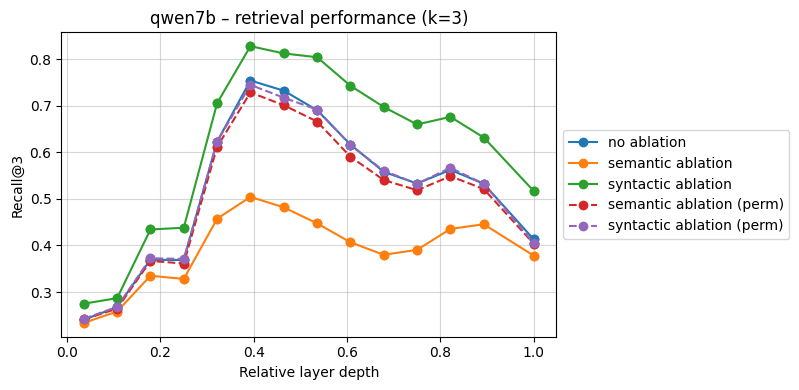

In [2]:
# Convert to numpy just to be safe
layer_vals_arr = np.array(layer_vals)
rel_depths = layer_vals_arr / depths[model_name]

# Plot recalls vs relative depth
fig, ax = plt.subplots(figsize=(7, 4))

plt.plot(rel_depths, recalls_0, marker='o', label='no ablation')
plt.plot(rel_depths, recalls_sem, marker='o', label='semantic ablation')
plt.plot(rel_depths, recalls_syn, marker='o', label='syntactic ablation')
plt.plot(rel_depths, recalls_sem_perm, marker='o', linestyle='--',
          label='semantic ablation (perm)')
plt.plot(rel_depths, recalls_syn_perm, marker='o', linestyle='--',
          label='syntactic ablation (perm)')

# Optional: scatter on top for a bit more emphasis (your alpha prefs)
plt.scatter(rel_depths, recalls_0, alpha=0.9)
plt.scatter(rel_depths, recalls_sem, alpha=0.9)
plt.scatter(rel_depths, recalls_syn, alpha=0.9)
plt.scatter(rel_depths, recalls_sem_perm, alpha=0.9)
plt.scatter(rel_depths, recalls_syn_perm, alpha=0.9)

plt.xlabel('Relative layer depth')
plt.ylabel(f'Recall@{k_recall}')
plt.title(f'{model_name} – retrieval performance (k={k_recall})')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig_path = os.path.join(resultsfolder, f"recall_k{k_recall}.png")
# plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()



In [3]:
normalization_flag = 1
shuffled_controls = [0,1]

for shuffled_control_id,shuffled_control in enumerate(shuffled_controls):
    resultsfolder = makefolder(base='./results/syntax_classification/',
                           model_name=model_name,
                           avg_tokens=avg_tokens,
                           normalization_flag=normalization_flag,
                           shuffled_control=shuffled_control,
                           )

    results = np.load(resultsfolder+'results.npz')

    # syn_layer_indices   = results['layer_indices']
    if shuffled_control == 0:
      syn_accs_A = results['accs_A']
      syn_ablated_syn_accs_A = results['syn_ablated_accs_A']
      sem_ablated_syn_accs_A = results['sem_ablated_accs_A']
    elif shuffled_control == 1:
      syn_ablated_syn_accs_A_perm = results['syn_ablated_accs_A']
      sem_ablated_syn_accs_A_perm = results['sem_ablated_accs_A']

In [5]:
import os
import numpy as np

# --- load retrieval results (same config you used when saving) ---
k_recall = 3  # or whatever you used

recall_resultsfolder = makefolder(
    base='results/recall/sem/',
    create_folder=False,   # just loading
    model_name=model_name,
    avg_tokens=avg_tokens,
    min_token_length=min_token_length,
    global_center_flag=global_center_flag,
    k=k_recall,
)

recall_npz_path = os.path.join(recall_resultsfolder, f"recall_k{k_recall}.npz")
recall_data = np.load(recall_npz_path)

recalls_0        = recall_data["recalls_0"]
recalls_sem      = recall_data["recalls_sem"]
recalls_syn      = recall_data["recalls_syn"]
recalls_sem_perm = recall_data["recalls_sem_perm"]
recalls_syn_perm = recall_data["recalls_syn_perm"]

# --- best over layers for each condition ---

def fmt_num(x):
    return f"{x:.2f}"

# retrieval
best_recalls = [
    recalls_0.max(),         # no ablation
    recalls_sem.max(),       # semantic ablation
    recalls_syn.max(),       # syntactic ablation
    recalls_sem_perm.max(),  # semantic ablation (perm)
    recalls_syn_perm.max(),  # syntactic ablation (perm)
]

# syntax classification
# mapping rows so that the labels match the retrieval experiment:
#   no ablation              -> syn_accs_A
#   semantic ablation        -> sem_ablated_syn_accs_A
#   syntactic ablation       -> syn_ablated_syn_accs_A
#   semantic ablation (perm) -> sem_ablated_syn_accs_A_perm
#   syntactic ablation (perm)-> syn_ablated_syn_accs_A_perm
best_accs = [
    syn_accs_A.max(),
    sem_ablated_syn_accs_A.max(),
    syn_ablated_syn_accs_A.max(),
    sem_ablated_syn_accs_A_perm.max(),
    syn_ablated_syn_accs_A_perm.max(),
]

row_labels = [
    r"\shortstack{baseline\\(no ablation)}",
    "semantic ablation",
    "syntactic ablation",
    r"\shortstack{semantic ablation\\(random)}",
    r"\shortstack{syntactic ablation\\(random)}",
]

# Find max/min for recalls and accuracies
max_recall = float(np.max(best_recalls))
min_recall = float(np.min(best_recalls))
max_acc    = float(np.max(best_accs))
min_acc    = float(np.min(best_accs))

def style_val(x, max_val, min_val):
    s = fmt_num(x)
    if np.isclose(x, max_val):
        return r"\underline{" + s + "}"   # biggest
    elif np.isclose(x, min_val):
        return r"\textbf{" + s + "}"      # smallest
    else:
        return s


lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{|c|c|c|}")
lines.append(r"\hline")
lines.append(
    rf" & \shortstack{{Best\\P-recall@{k_recall}}} & "
    r"\shortstack{Best\\syntax-acc} \\"
)
lines.append(r"\hline")

for label, r_val, a_val in zip(row_labels, best_recalls, best_accs):
    lines.append(
        f"{label} & "
        f"{style_val(r_val, max_recall, min_recall)} & "
        f"{style_val(a_val, max_acc, min_acc)} \\\\\hline"
    )

# lines.append(r"\hline")
lines.append(r"\end{tabular}")
lines.append(
    r"\caption{Best Paraphrase-recall@3 (first column) and best syntax classification accuracy (second column) across layers for qwen7b. Bold and underlined numbers correspond to the minimum and maximum values of each collumn, respectively}")
lines.append(r"\end{table}")


latex_table = "\n".join(lines)

# --- save the table (choose where; here I put it with the recall results) ---
tablefolder = 'results/table/'
os.makedirs(tablefolder, exist_ok=True)
table_path = os.path.join(tablefolder, f"combined_recall_syntax_k{k_recall}.txt")
with open(table_path, "w") as f:
    f.write(latex_table)

print(f"Saved LaTeX table to {table_path}")


Saved LaTeX table to results/table/combined_recall_syntax_k3.txt
